In [21]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 1):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


## TESTS

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


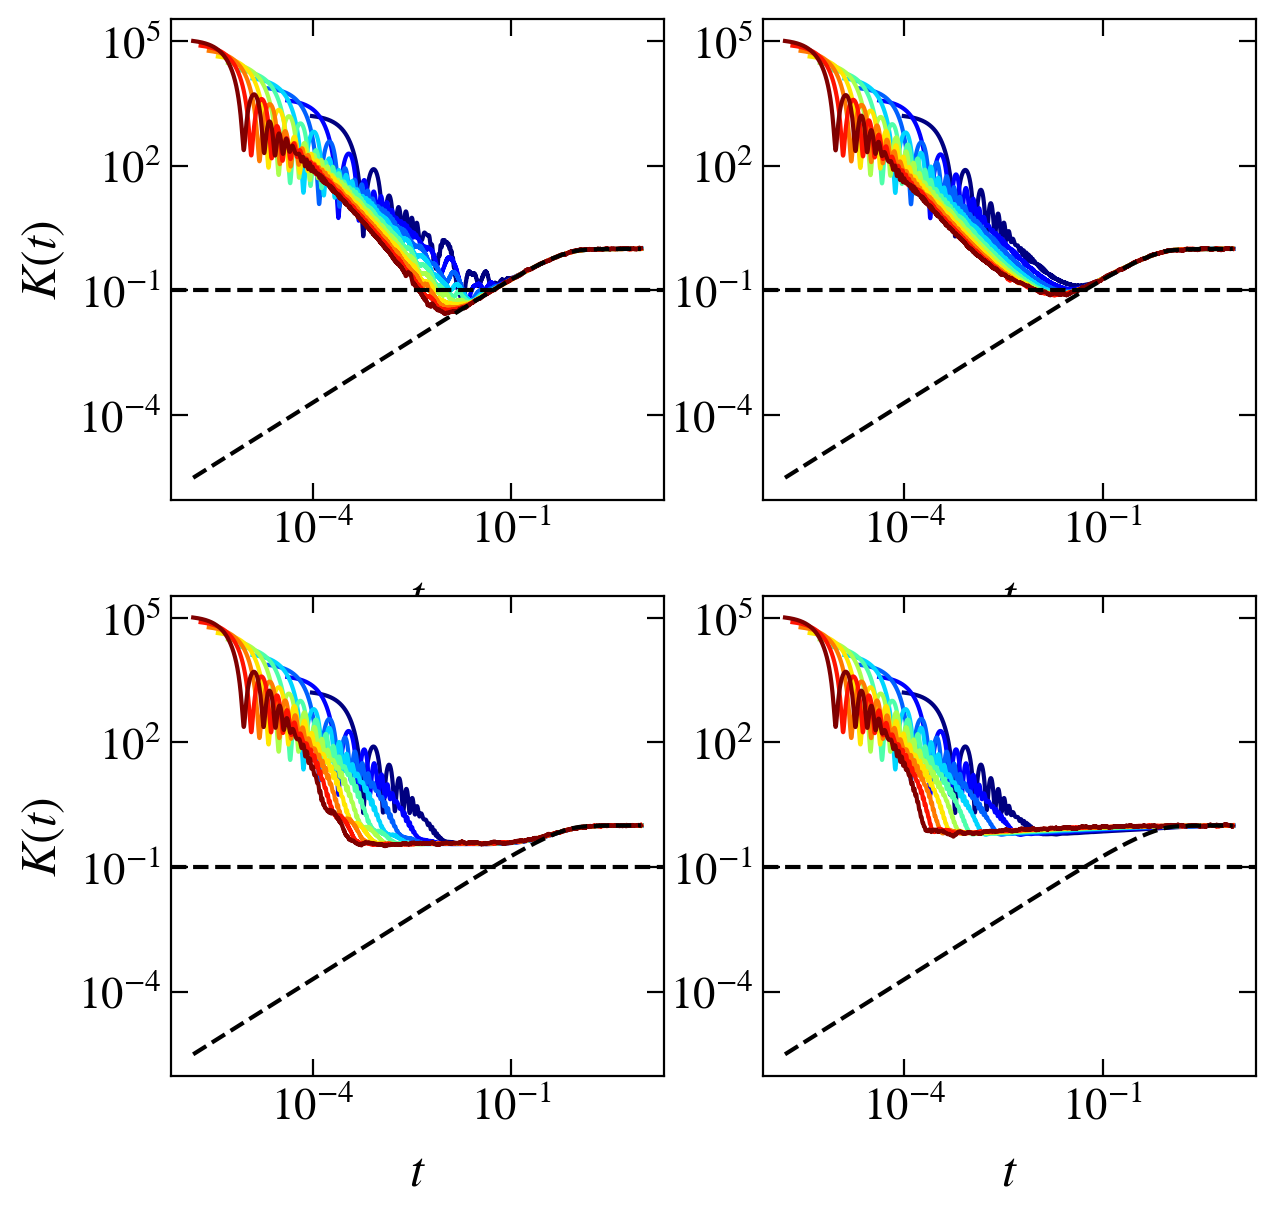

In [3]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 15, 1)
elif DIM == 5:  sizes = np.arange(3, 9, 1)

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(7,7), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
# Ws = [6, 15, 39, 75]
if DIM == 3:    Ws = [4, 10, 16, 24]
elif DIM == 4:  Ws = [6, 20, 34, 46]
elif DIM == 5:  Ws = [8, 15, 57, 75]
else: Ws = []
labs = ["(a)", "(b)", "(c)", "(d)"]

cut = 0.1
window = 50
for iia, Wx in enumerate(Ws):

    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
    
        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]# / tH
                # sff = np.array(file.get('sff_eps'))[:,-1]
                sff = np.array(file.get('sff_raw'))[0]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                # sff = np.log10( sff / goe.spectral_form_factor(times))
                axis[iia].plot(times, sff, color=col)
        else:
            print(name)       
    axis[iia].plot(times, goe.spectral_form_factor(times), ls='--', color='k')
    axis[iia].axhline(y=cut, ls='--', color='k')
    fig_help.set_plot_elements(axis[iia], ylabel=r"$K(t)$" if iia%2 == 0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')  

0.02
0.02
0.02
0.02
0.02
0.02


No handles with labels found to put in legend.


0.02
0.02
0.02
0.02
0.06
0.06
0.06
0.06
0.06
0.06


No handles with labels found to put in legend.


0.06
0.06
0.06
0.06
0.22
0.22
0.22
0.22
0.22
0.22
0.22


No handles with labels found to put in legend.


0.22
0.22
0.22
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5


No handles with labels found to put in legend.


0.5


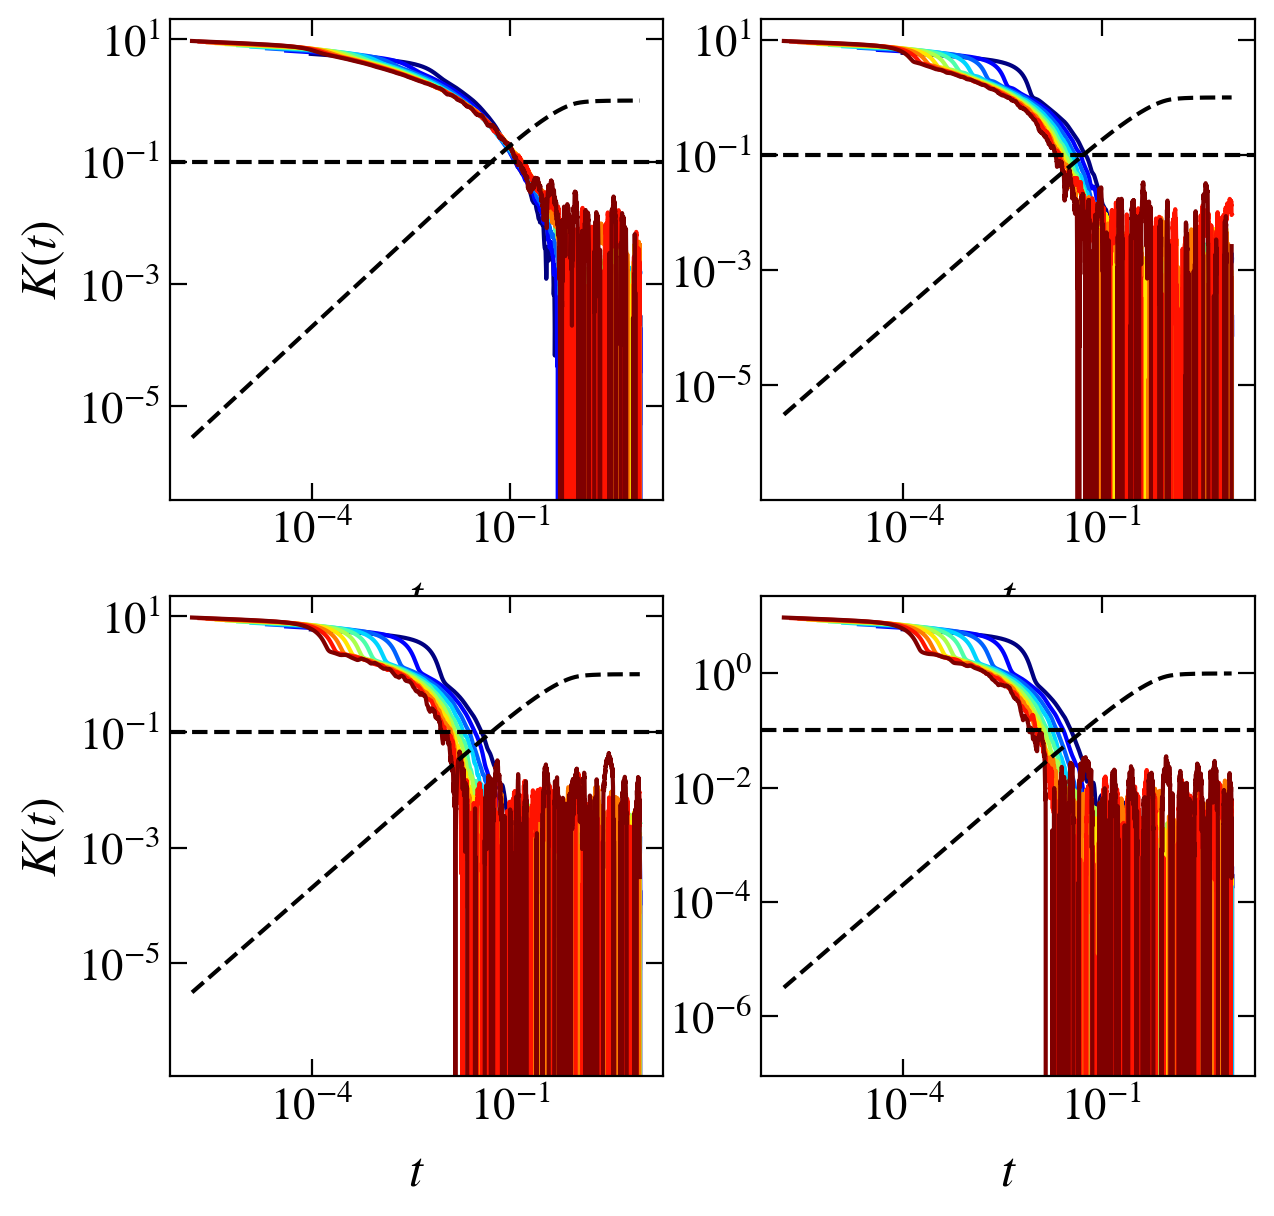

In [4]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 15, 1)
elif DIM == 5:  sizes = np.arange(3, 9, 1)

import matplotlib.pyplot as plt
fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(7,7), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
Ws = [6, 15, 39, 75]
labs = ["(a)", "(b)", "(c)", "(d)"]

cut = 0.1
window = 50
beta_idx = [0, 2, 10, -1]

Wx = 5
# Ws = [6, 15, 39, 75]
if DIM == 3:    Wx = 10
elif DIM == 4:  Wx = 20
elif DIM == 5:  Wx = 30
else: Wx = 0

for iia, iieps in enumerate(beta_idx):
    ymin = 1e6
    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
    
        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH_typ'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]
                sff = np.array(file.get('sff_eps'))[:,iieps]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                eps = np.array(file.get('energy_densities'))[0]
                print(eps[iieps])
                sff = np.log10( sff / goe.spectral_form_factor(times))
                axis[iia].plot(times, sff, color=col)
                if np.min(sff) < ymin: ymin = np.min(sff)
        else:
            print(name)       
    axis[iia].plot(times, goe.spectral_form_factor(times), ls='--', color='k')
    axis[iia].axhline(y=cut, ls='--', color='k')
    fig_help.set_plot_elements(axis[iia], ylabel=r"$K(t)$" if iia%2 == 0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')  
    # axis[iia].set_ylim(ymin/2, 1.2)

0.5 12
0.5 16
0.5 20
0.5 24
0.5 28
0.5 32
0.5 36
0.5 40
0.5 44
0.5 48


No handles with labels found to put in legend.


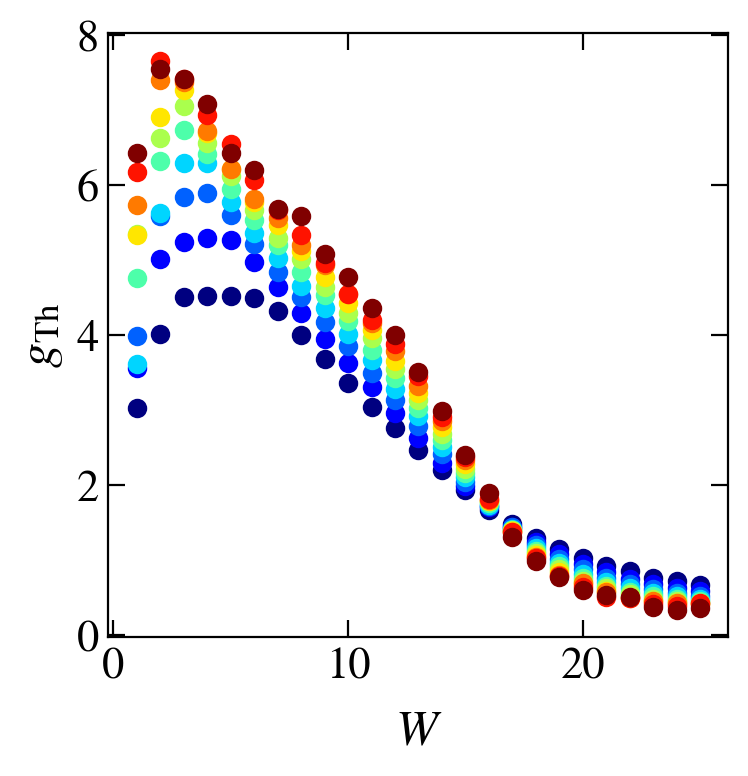

In [5]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 15, 1)
elif DIM == 5:  sizes = np.arange(3, 9, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex=False, sharey=False)
# axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
if DIM == 3:    Ws = np.arange(1, 26, 1);   Wmin = 4; Wmax = 30
elif DIM == 4:  Ws = np.arange(2, 51, 2);   Wmin = 4; Wmax = 60
elif DIM == 5:  Ws = np.arange(3, 76, 3);   Wmin = 6; Wmax = 80
else: Ws = []

labs = ["(a)", "(b)", "(c)", "(d)"]

window = 100
cut = 0.1
for eps in np.arange(0.5, 0.51, 0.02):
    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        thouless = np.zeros(Ws.shape); thouless.fill(np.nan)
        tH = np.zeros(Ws.shape); tH.fill(np.nan)
        tH_typ = np.zeros(Ws.shape); tH_typ.fill(np.nan)
        gap_ratio = np.zeros(Ws.shape); gap_ratio.fill(np.nan)
        gap_ratio_500 = np.zeros(Ws.shape); gap_ratio_500.fill(np.nan)
        print(eps, L)
        for iia, Wx in enumerate(Ws):
            name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
        
            if exists(name):
                with h5py.File(name, "r") as file:
                    tH[iia] = np.array(file.get('tH'))[0]
                    tH_typ[iia] = np.array(file.get('tH_typ'))[0]
                    gap_ratio[iia] = np.array(file.get('r_500'))[0]
                    gap_ratio_500[iia] = np.array(file.get('r_D_2'))[0]
                    
                    R = np.array(file.get('realisations'))[0]
                    
                    E = np.array(file.get('energy_densities'))[0]
                    idxE = np.argmin( np.abs(E - eps) )
                    # print(L, Wx, R)
                    times = np.array(file.get('times'))[0]
                    sff = np.array(file.get('sff_eps'))[:, idxE]
                    
                    sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                    times = times[window//2:-window//2]
                    
                    diff = np.log10( sff / goe.spectral_form_factor(times))
                    idx = np.argmin( np.abs(diff - cut) )
                    thouless[iia] = np.log(1 / times[idx])
            else:
                print(name)       
        axis.scatter(Ws, thouless, color=col)
        
        folder = f'./thouless time/Anderson/d=%d/'%DIM
        os.makedirs(folder, exist_ok=True)
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, eps)
        hf = h5py.File(name_out, 'w')
        hf.create_dataset('disorder',                Ws.shape, data = Ws)
        hf.create_dataset('thouless time',           thouless.shape,   data = np.exp(-thouless) * tH )
        hf.create_dataset('thouless conductivity',   thouless.shape,   data = thouless)
        hf.create_dataset('heisenberg time',         tH.shape,         data = tH)
        hf.create_dataset('typical heisenberg time', tH_typ.shape,     data = tH_typ)
        hf.create_dataset('gap ratio',               gap_ratio.shape,  data = gap_ratio)
        hf.create_dataset('gap ratio 500',           gap_ratio_500.shape,  data = gap_ratio_500)
        hf.close()
        
    fig_help.set_plot_elements(axis, ylabel=r"$g_{\rm Th}$", xlabel=r"$W$", font_size=16, set_legend=1, xscale='linear', yscale='linear')  

6 32 [10000]
7 32 [10000]
8 32 [10000]
9 32 [9901]
10 32 [5588]
11 32 [4338]
12 32 [2505]
13 32 [1009]
14 32 [691]


No handles with labels found to put in legend.


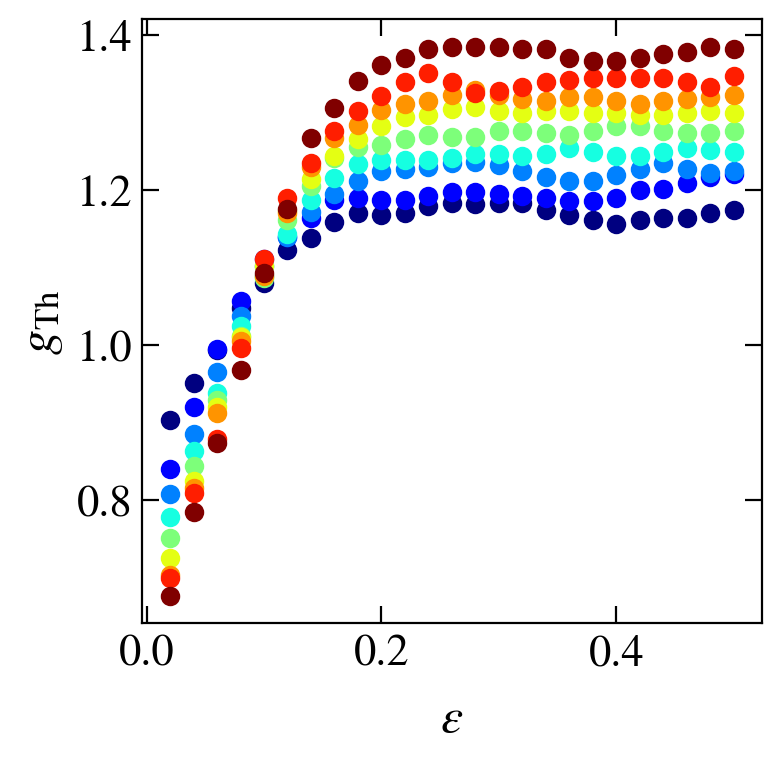

In [41]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 4
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

sizes = np.arange(12, 37, 4)
sizes = np.arange(6, 15, 1)
# sizes = np.arange(3, 8, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex=False, sharey=False)
# axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
Ws = np.arange(1, 26, 1)
Ws = np.arange(2, 51, 2)
labs = ["(a)", "(b)", "(c)", "(d)"]


Wx = 32
window = 50
cut = 0.1
for ii, L in enumerate(sizes):
    
    col = s_m.to_rgba(L)
    
    name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            tH = np.array(file.get('tH'))[0]
            eps = np.array(file.get('energy_densities'))[0]
            
            R = np.array(file.get('realisations'))[0]
            print(L, Wx, R)
            
            thouless = np.zeros(eps.shape)
            for iib, beta in enumerate(eps):
                times = np.array(file.get('times'))[0]
                sff = np.array(file.get('sff_eps'))[:,iib]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                diff = np.log10( sff / goe.spectral_form_factor(times))
                idx = np.argmin( np.abs(diff - cut) )
                thouless[iib] =  np.log(1 / times[idx])
            
            axis.scatter(eps, thouless, color=col)
    else:
        print(name)       
    
    
fig_help.set_plot_elements(axis, ylabel=r"$g_{\rm Th}$", xlabel=r"$\epsilon$", font_size=16, set_legend=1, xscale='linear', yscale='linear')  

## BETA FUNCTION

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


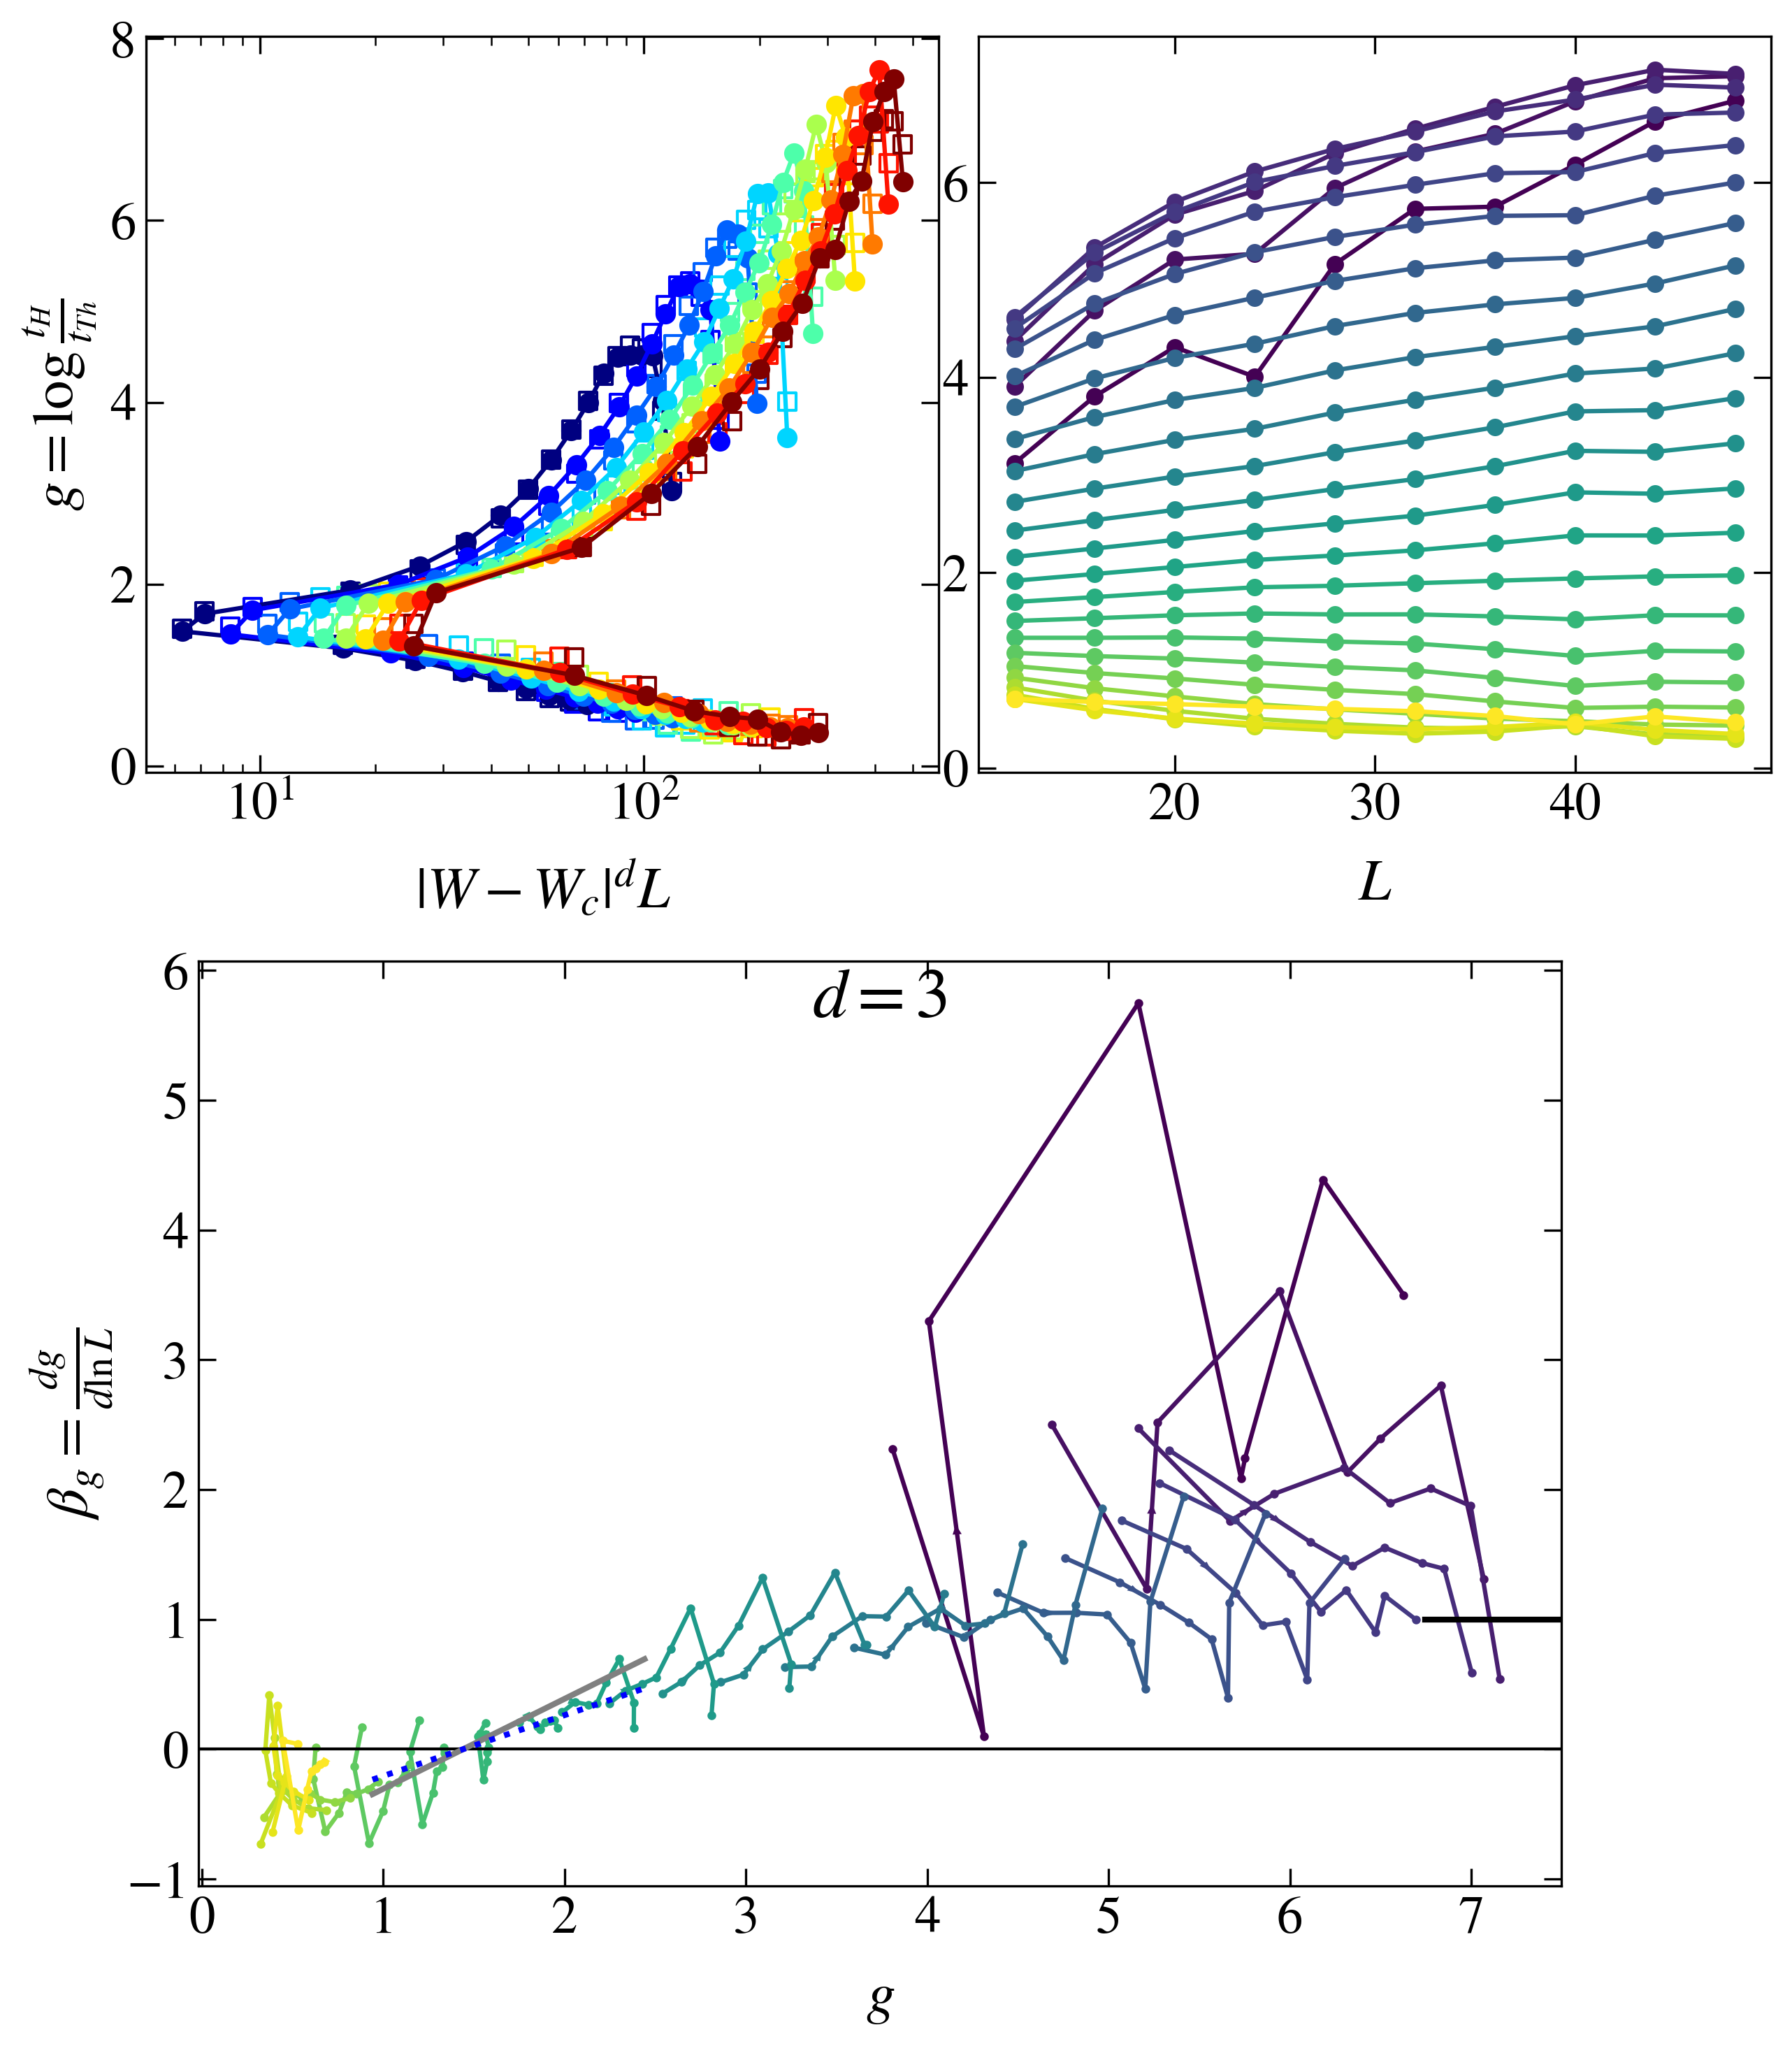

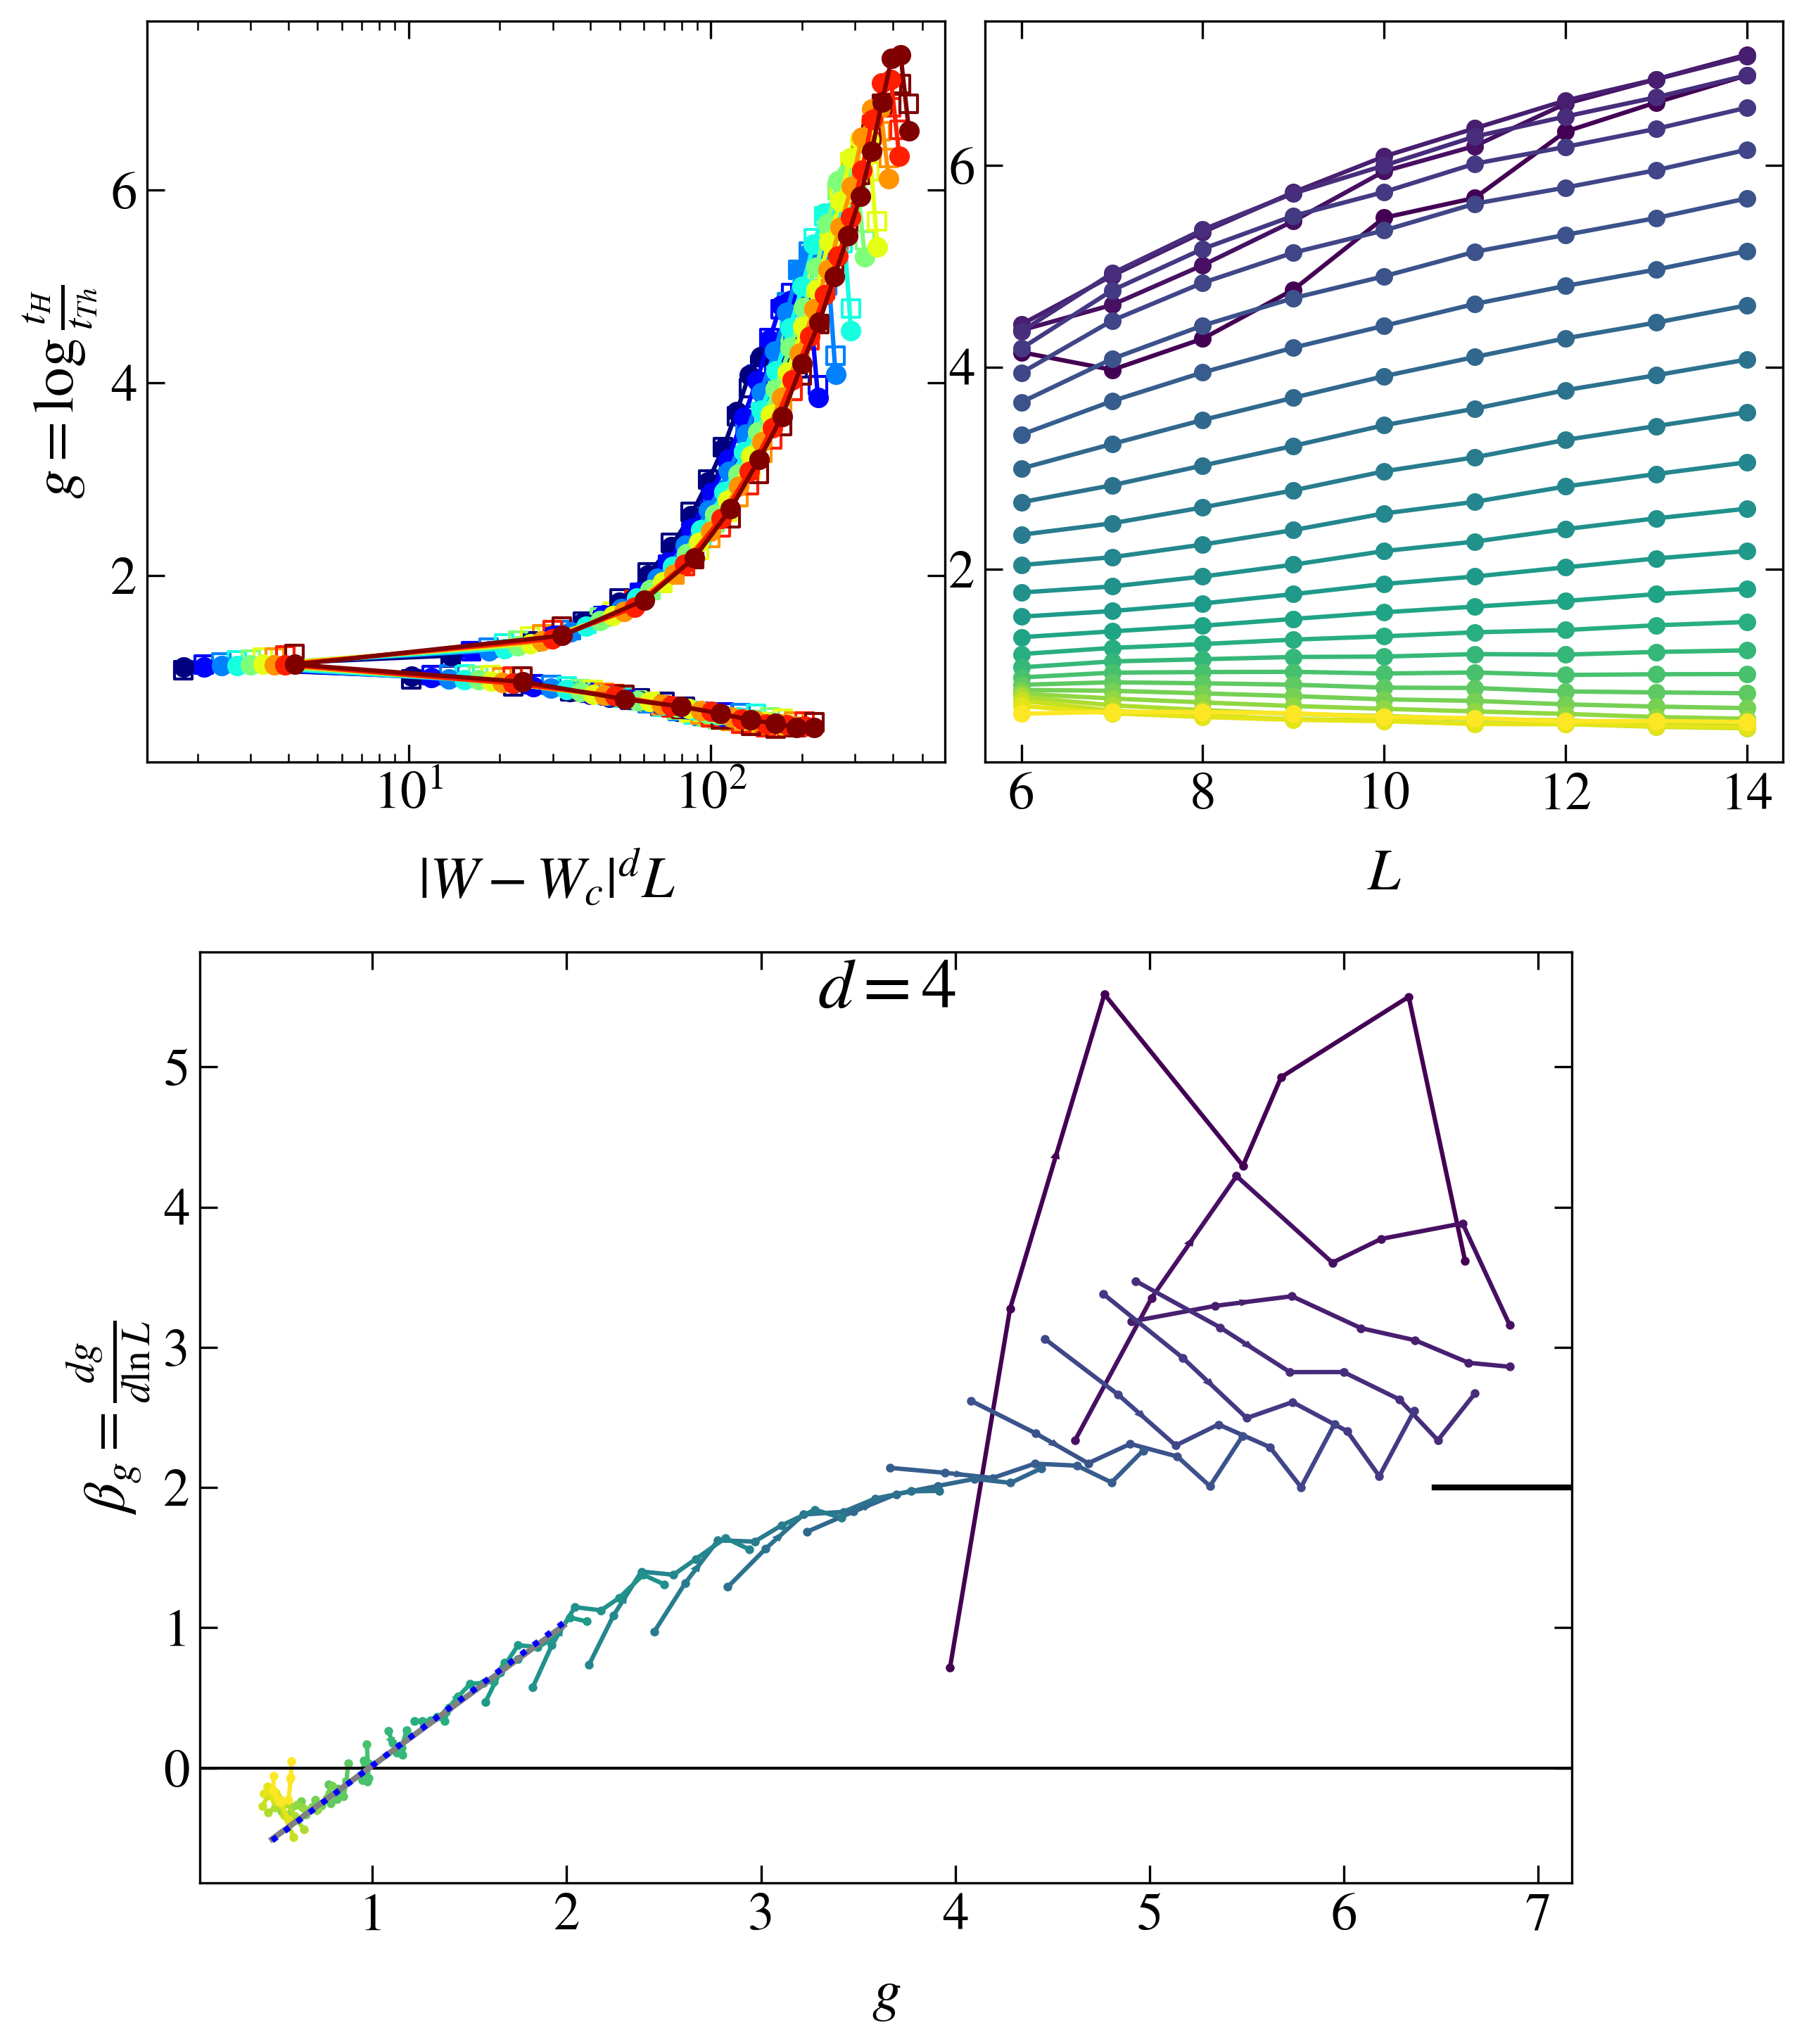

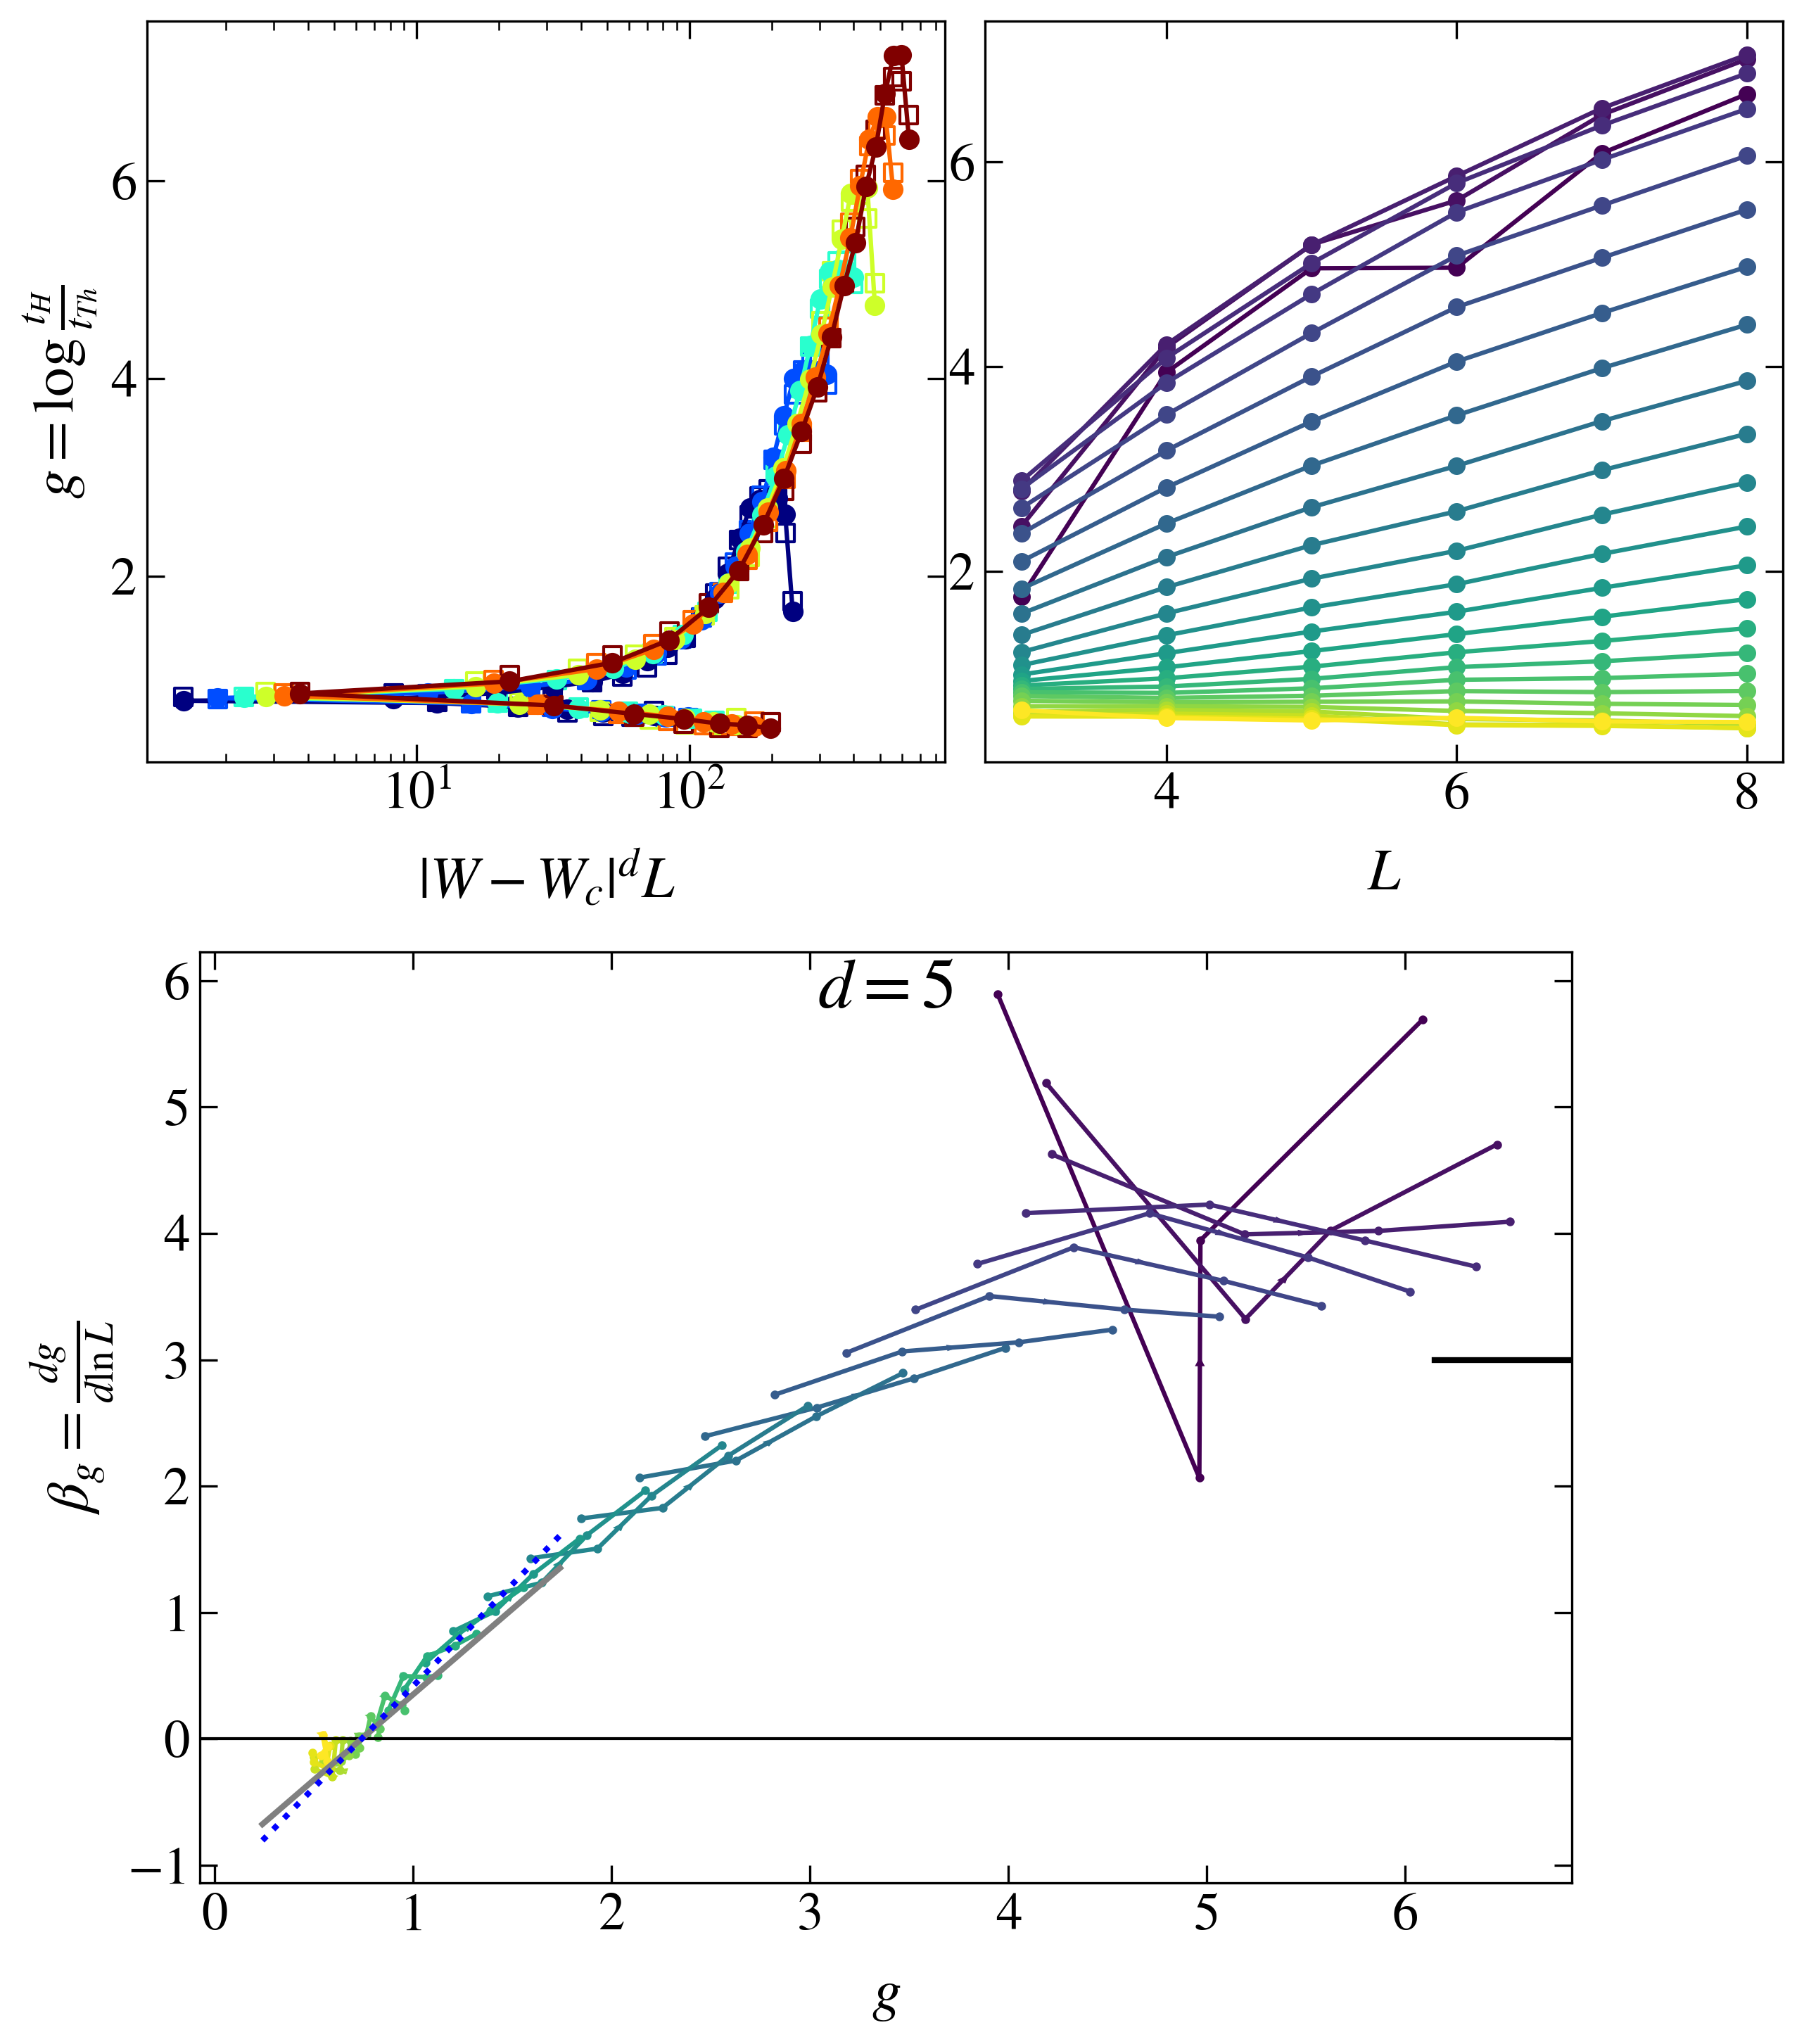

In [23]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'

use_fit = 0
DIM = 3
eps = 0.5


for DIM in range(3, 6):
    

    def th_fit(L, a, b, c, d):
        # return A * g / xi
        return (L**(DIM-1) + a * L**(DIM-2) + b) / (L**(DIM-1) + c * L**(DIM-2) + d)

    def th_fit2(L, a, b, c, k):
        return a * np.exp(-b*L) * (L + c) / (L + k)
        # return -g / xi + A
    prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

    folder = f'./thouless time/Anderson/d=%d/'%DIM

    if DIM == 3:    sizes = np.arange(12, 49, 4)
    elif DIM == 4:  sizes = np.arange(6, 15, 1)
    elif DIM == 5:  sizes = np.arange(3, 9, 1)


    fig = plt.figure(figsize=(10,9), dpi = 300)
    gs1 = GridSpec(1, 1)
    gs1.update(top=0.51, bottom=0.02, left=0.15, right=0.8)
    axis = fig.add_subplot(gs1[0,0])

    gs2 = GridSpec(1, 2)
    gs2.update(top=1, bottom=0.61, wspace=0.05, hspace=0.25)
    ax1 = fig.add_subplot(gs2[0])
    ax2 = fig.add_subplot(gs2[1])
    axis = [axis, ax1, ax2]

    norm = matplotlib.colors.Normalize(
            vmin=min(sizes),
            vmax=max(sizes))
    s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
    s_m.set_array([])

    r_idx = 5
    corr = 0
    Ws = [2, 6, 10, 16]

    if DIM == 3:    Ws = np.arange(1, 26, 1);   Wmin = 1; Wmax = 30; W_crit = 16.54;    nu = 1.48
    elif DIM == 4:  Ws = np.arange(2, 51, 2);   Wmin = 2; Wmax = 60; W_crit = 34.30;    nu = 0.98
    elif DIM == 5:  Ws = np.arange(3, 76, 3);   Wmin = 3; Wmax = 80; W_crit = 56.50;    nu = 0.84
    else: Ws = []

    labs = ["(a)", "(b)", "(c)", "(d)"]


    norm = matplotlib.colors.Normalize(
        vmin=np.min(sizes),
        vmax=np.max(sizes))

    # create a ScalarMappable and initialize a data structure
    s_m_L = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
    s_m_L.set_array([])



    window = 50
    cut = 0.1
    conductivity = []
    g_crit = 0
    count = 0
    for ii, L in enumerate(sizes):
        # name_out = folder + f'_L={L}.hdf5'
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, eps)
        
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ws  = np.array(file.get('disorder'))
                thouless  = np.array(file.get('thouless conductivity'))
                
                idx = np.argmin( np.abs(Ws - W_crit))
                g_crit += thouless[idx]
                count +=1 
                
                indices = np.where(np.logical_and(Ws >= Wmin, Ws < Wmax))[0]
                Ws = Ws[indices]
                thouless = thouless[indices]
                # Ws = Ws[~np.isnan(thouless)]
                # thouless = thouless[~np.isnan(thouless)]
                
                tH  = np.array(file.get('heisenberg time'))
                tH_typ  = np.array(file.get('typical heisenberg time'))
                gap_ratio  = np.array(file.get('gap ratio'))
                
                def rescaleW(Wx):
                    return np.abs(Wx - W_crit)**(0.5 + (DIM-2) / DIM) * L
                
                axis[1].plot(rescaleW(Ws), thouless, marker='o', color = s_m_L.to_rgba(L))
                
                # if interpolate:
                f = splrep(Ws, thouless, k=5, s=1)
                # Ws = np.linspace(xx[0], xx[-1], xx.size + (xx.size-1) * 2)
                thouless = splev(Ws, f)
                conductivity.append(thouless)
                
                axis[1].scatter(rescaleW(Ws), thouless, marker='s', color = s_m_L.to_rgba(L), facecolor='None')
        else:
            print(name_out)
    g_crit /= count
    fig_help.set_plot_elements(axis[1], ylabel=r"$g=\log\frac{t_H}{t_{Th}}$", xlabel=r"$|W-W_c|^dL$", font_size=18, set_legend=False, xscale='log', yscale='linear')
    # fig_help.set_legend(axis[1], fontsize=16, loc='upper right', anchor=(1.03, 1.03))

    conductivity = np.transpose( np.array(conductivity) )
    norm = matplotlib.colors.Normalize(
        vmin=np.min(Ws),
        vmax=np.max(Ws) )
    # create a ScalarMappable and initialize a data structure
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
    s_m.set_array([])


    yax_max = -10
    yax_min = 10
    envelope_xdata = []
    envelope_ydata = []
    for iiw, Wx in enumerate(Ws):
        col = s_m.to_rgba(Wx)
        # col = s_m.to_rgba(alfa)
        yy = conductivity[iiw]
        xx = sizes[~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        
        if not use_fit:
            axis[2].plot(xx, yy, marker='o', markersize=5, color=col)
            
            beta = diff_central( np.log(xx), (yy))# * xx[1:-1] / yy[1:-1]
            xx_beta = yy[1:-1]

            line, = axis[0].plot(xx_beta, beta, marker='o', markersize=2, lw=1.5, color=col)
            
            envelope_ydata = [*envelope_ydata, *beta]
            envelope_xdata = [*envelope_xdata, *xx_beta]
            # envelope_ydata = [*envelope_ydata, (beta[-1])]
            # envelope_xdata = [*envelope_xdata, (xx_beta[-1])]
            
            if min(beta) < yax_min: yax_min = min(beta)
            if max(beta) > yax_max: yax_max = max(beta)
            
            i1 = 1
            dx = xx_beta[i1+1] - xx_beta[i1]
            dy = beta[i1+1] - beta[i1]
            pos_x = xx_beta[i1] + dx/2
            pos_y = beta[i1] + dy/2
            
            axis[0].arrow(pos_x, pos_y, 0.01 * dx, 0.01 * dy, shape='full', lw=0, length_includes_head=True, head_width=.05, color=col)
        else:
            my_fit = th_fit if Wx <= W_crit else th_fit2
            try:
                # xx = xx - N
                axis[2].scatter(xx, yy, marker='o', s=30, color=col)
                
                pars, pconv, fit_info, msg, _ = fit(my_fit,
                                xdata = xx,
                                ydata = yy,
                                full_output=True, maxfev=10000)
                # print(J, alfa, fit_info['fvec'])
                dense_sizes = np.linspace(xx[0]-1, xx[-1]+1, 10000)
                
                axis[2].plot(dense_sizes, my_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            except RuntimeError:
                print(g, "Failed")
            dense_sizes = np.linspace(xx[0], xx[-1], 50)
            smooth_data = my_fit(dense_sizes, *pars)
            
            deriv = diff_central(np.log(dense_sizes), (smooth_data))
            smooth_data = smooth_data[1:-1]
            axis[0].plot(smooth_data, deriv, lw=1.5, color=col)
            
            if min(deriv) < yax_min: yax_min = min(deriv)
            if max(deriv) > yax_max: yax_max = max(deriv)
            
            envelope_ydata = [*envelope_ydata, *deriv]
            envelope_xdata = [*envelope_xdata, *smooth_data]

            i1 = smooth_data.size // 2
            dx = smooth_data[i1+1] - smooth_data[i1]
            dy = deriv[i1+1] - deriv[i1]
            pos_x = smooth_data[i1] + dx/2
            pos_y = deriv[i1] + dy/2
            axis[0].arrow(pos_x, pos_y, 0.01 * dx, 0.01 * dy, shape='full', lw=0, length_includes_head=True, head_width=.05, color=col)
        
    fig_help.set_plot_elements(axis[2], ylabel="", xlabel=r"$L$", font_size=18, set_legend=False, xscale='linear', yscale='linear')

    axis[0].axhline(y=0, ls='-', c='k', lw=1)
    axis[0].axhline(y=DIM-2, ls='-', c='black', lw=2, xmin = 0.9)
    # inset.axvline(x=0, ls='--', c='k', lw=1)

    permut = np.argsort( np.array(envelope_xdata) )
    envelope_ydata = np.array(envelope_ydata)[permut]
    envelope_xdata = np.array(envelope_xdata)[permut]

    f = splrep(envelope_xdata, envelope_ydata, k=5, s=10)
    xx = np.linspace(envelope_xdata[0], envelope_xdata[-1], 10000)
    envelope_ydata = splev(xx, f)
    # axis[0].plot(xx, envelope_ydata, color='k', ls='--')

    g_crit = xx[ np.argmin( np.abs(envelope_ydata) ) ]
    gs = np.linspace(g_crit - 0.5, g_crit + 1., 1000)
    axis[0].plot(gs, (gs - g_crit) / (g_crit), ls='-', color='gray', lw=2)
    axis[0].plot(gs, (gs - g_crit) / (g_crit * nu), ls=':', color='blue', lw=2)

    gs = np.linspace(min(envelope_xdata), max(envelope_xdata), 1000)
    # axis[0].plot(gs, (DIM-2) * (1 - g_crit / (gs)), lw=2, ls='-', color='gray', label=r"$\beta_{sp}(g_{\rm Th})$")

    # gs = np.linspace(2 * gth_crit, gmax, 1000)
    # axis[0].plot(gs, 1 + 2 / gs, lw=1, ls='-.', color='r', label=r"$\beta_{ETH}(g_{\rm Th})$")


    # axis[0].plot(np.nan, np.nan, lw=1, ls=':', color='k', label=r"$\beta(g_{\rm Th},\gamma)$")

    xlab = r"$g$"
    ylab = r"${\beta}_g=\frac{dg}{d\ln{L}}$"
    fig_help.set_plot_elements(axis[0], xlabel=xlab, ylabel=ylab, font_size=18, set_legend=False, xscale='linear')
    fig_help.set_legend(axis[0], loc = 'upper left', fontsize=14, anchor=(0.02, 0.91))
    
    axis[0].annotate(r"$d=%d$"%DIM, fontsize=24, xy=(0.45, 0.94), xycoords='axes fraction')

In [1]:
print(9**5, 10**5, 11**5, 17**4, 18**4, 19**4, 20**4, 48**3, 52**3, 56**3)
print(15**4)

# Implement kappa (openness) to make single-realisations thouless time

59049 100000 161051 83521 104976 130321 160000 110592 140608 175616
50625
